# Stack Overflow Developer Survey Analysis

## Overview

This project explores the Stack Overflow Developer Survey dataset using Python and Pandas.

The analysis focuses on:
- Python popularity
- Developer compensation
- Remote work trends
- Education and learning paths
- Industry analysis

## Data Loading
Loading the Stack Overflow Developer Survey dataset.

In [1]:
from google.colab import files
uploaded = files.upload()

Saving survey_results_public.csv to survey_results_public.csv


In [2]:
from google.colab import files
uploaded = files.upload()

Saving survey_results_schema.csv to survey_results_schema.csv


In [3]:
import pandas as pd
df = pd.read_csv("survey_results_public.csv")
schema = pd.read_csv("survey_results_schema.csv")

/tmp/ipykernel_714/1407751156.py:2: DtypeWarning: Columns (56,74,92,97,98,105,109,110,132,162,165) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("survey_results_public.csv")


## Data Exploration

Exploring dataset structure, columns, and missing values.


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49191 entries, 0 to 49190
Columns: 172 entries, ResponseId to JobSat
dtypes: float64(52), int64(1), object(119)
memory usage: 64.6+ MB


## Total Number of Respondents

Calculating the total number of survey respondents.

In [5]:
total_respondents = df.shape[0]

respondents_df = pd.DataFrame({'Metric': ['Total Respondents'],'Value': [total_respondents]})
respondents_df

,Metric,Value
0,Total Respondents,49191


## Complete Responses Analysis

Identifying respondents who provided answers to all survey questions.

In [6]:
questions = set(schema['qname'])
survey_columns = list(questions.intersection(df.columns))
complete_responses = (df[survey_columns].notna().all(axis=1).sum())
complete_responses_df = pd.DataFrame({'Metric': ['Respondents Who Answered All Questions'],'Value': [complete_responses]})

complete_responses_df

,Metric,Value
0,Respondents Who Answered All Questions,0


## Work Experience Statistics


Calculating key measures of central tendency for respondents' work experience:
- Mean
- Median
- Mode

In [7]:
mean_workexp = round(df['WorkExp'].mean(), 2)
median_workexp = df['WorkExp'].median()
mode_workexp = df['WorkExp'].mode()[0]

workexp_stats_df = pd.DataFrame({'Metric': ['Mean', 'Median', 'Mode'],'Value': [mean_workexp, median_workexp, mode_workexp]})
workexp_stats_df

,Metric,Value
0,Mean,13.37
1,Median,10.00
2,Mode,10.00


### Insight

The average work experience is higher than the median, which may indicate the presence of respondents with significantly more years of experience, pulling the mean upward.

## Remote Work
Identifying the number of respondents who work remotely.

In [8]:
remote_workers = df[df['RemoteWork'].str.contains('Remote', na=False)].shape[0]
remote_percentage = round(remote_workers / len(df) * 100, 2)
remote_work_df = pd.DataFrame({'Metric': ['Remote Workers', 'Remote Workers (%)'],'Value': [remote_workers, remote_percentage]})

remote_work_df

,Metric,Value
0,Remote Workers,10931.00
1,Remote Workers (%),22.22


### Insight

A significant portion of respondents work remotely, indicating that remote work remains a common employment format among developers.

## Python Popularity

Calculating the percentage of respondents who use Python as one of their programming languages.

In [9]:
python_users = df['LanguageHaveWorkedWith'].str.contains('Python',na=False)
python_count = python_users.sum()
python_percentage = round(python_users.mean() * 100,2)
python_popularity_df = pd.DataFrame({'Metric': ['Python Users','Python Users (%)'],'Value': [python_count,python_percentage]})

python_popularity_df

,Metric,Value
0,Python Users,18466.00
1,Python Users (%),37.54


### Insight

Approximately 37.5% of respondents reported using Python, making it one of the most widely used programming languages in the survey.

## Learning Methods

Analyzing how many respondents learned programming through online courses and certifications.



In [11]:
online_courses = df['LearnCode'].str.contains('Online Courses or Certification', na=False)
online_courses_count = online_courses.sum()
online_courses_percentage = round(online_courses.mean() * 100,2)

online_courses_df = pd.DataFrame({'Metric': ['Respondents Who Used Online Courses','Respondents Who Used Online Courses (%)'],'Value': [online_courses_count, online_courses_percentage]})

online_courses_df

,Metric,Value
0,Respondents Who Used Online Courses,10973.00
1,Respondents Who Used Online Courses (%),22.31


### Insight
Online courses are one of the most common learning methods among developers.

## Compensation by Country

Analyzing average and median annual compensation of Python developers across different countries.

In [13]:
python_devs = df[df['LanguageHaveWorkedWith'].str.contains('Python', na=False)]
compensation_df = (python_devs.groupby('Country')['ConvertedCompYearly'].agg(['mean', 'median']).round(2).reset_index())
compensation_df.columns = ['Country','Average Compensation','Median Compensation']

compensation_df

,Country,Average Compensation,Median Compensation
0,Afghanistan,22328.67,1000.0
1,Albania,47217.60,50000.0
2,Algeria,20187.29,7088.0
3,Andorra,226103.50,226103.5
4,Angola,NaN,NaN
...,...,...,...
162,"Venezuela, Bolivarian Republic of...",9908.65,3000.0
163,Viet Nam,218837.17,8254.0
164,Yemen,32929.50,23672.0
165,Zambia,5424.25,3206.0


### Insight

Both average and median compensation vary considerably between countries, suggesting differences in local labor markets.

## Education of Top Earners

Analyzing the education levels of the five highest-paid respondents.

In [15]:
top_5_education = (df.dropna(subset=['ConvertedCompYearly']).sort_values(by='ConvertedCompYearly', ascending=False)[['ConvertedCompYearly', 'EdLevel']].head(5))
top_5_education.columns = ['Annual Compensation','Education Level']

education_df = pd.DataFrame(top_5_education)
education_df

,Annual Compensation,Education Level
34267,50000000.0,"Associate degree (A.A., A.S., etc.)"
28700,33552715.0,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)"
43143,18387548.0,"Associate degree (A.A., A.S., etc.)"
35353,15430267.0,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)"
45971,13921760.0,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)"


## Python Popularity by Age Group

Analyzing the percentage of respondents who use Python across different age groups.

In [16]:
python_by_age = (df.groupby('Age')['LanguageHaveWorkedWith'].apply(lambda x: x.str.contains('Python', na=False).mean() * 100).round(2).reset_index())
python_by_age.columns = ['Age Group','Python Users (%)']

python_by_age_df = pd.DataFrame(python_by_age)
python_by_age_df

,Age Group,Python Users (%)
0,18-24 years old,40.00
1,25-34 years old,36.94
2,35-44 years old,36.72
3,45-54 years old,38.63
4,55-64 years old,37.24
5,65 years or older,31.63
6,Prefer not to say,31.22


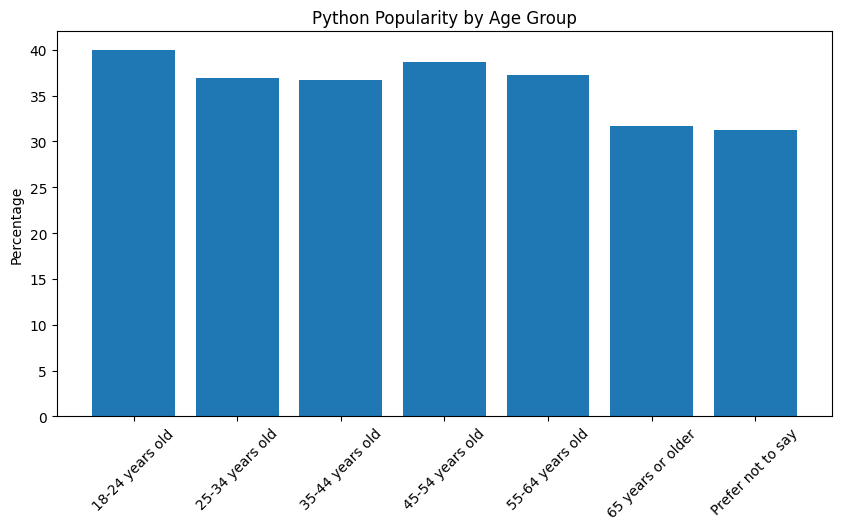

In [17]:
plt.figure(figsize=(10, 5))
plt.bar(python_by_age_df['Age Group'],python_by_age_df['Python Users (%)'])
plt.xticks(rotation=45)
plt.ylabel('Percentage')
plt.title('Python Popularity by Age Group')

plt.show()

### Insight

Python usage remains relatively consistent across age groups, ranging from approximately 31% to 40% of respondents.

## Industry Analysis of High-Paid Remote Workers

Identifying the most common industries among respondents who:
- Work remotely
- Earn more than the 75th percentile of annual compensation

In [18]:
salary_75_percentile = df['ConvertedCompYearly'].quantile(0.75)
high_paid_remote = df[(df['ConvertedCompYearly'] > salary_75_percentile) &(df['RemoteWork'].str.contains('Remote', na=False))]
top_industries = (high_paid_remote['Industry'].value_counts().sort_values(ascending=False).reset_index())
top_industries.columns = ['Industry','Number of Respondents']

top_industries_df = pd.DataFrame(top_industries)
top_industries_df

,Industry,Number of Respondents
0,Software Development,1186
1,Fintech,190
2,Healthcare,188
3,Other:,176
4,"Internet, Telecomm or Information Services",138
5,Banking/Financial Services,88
6,Government,78
7,Media & Advertising Services,75
8,Retail and Consumer Services,65
9,"Transportation, or Supply Chain",63


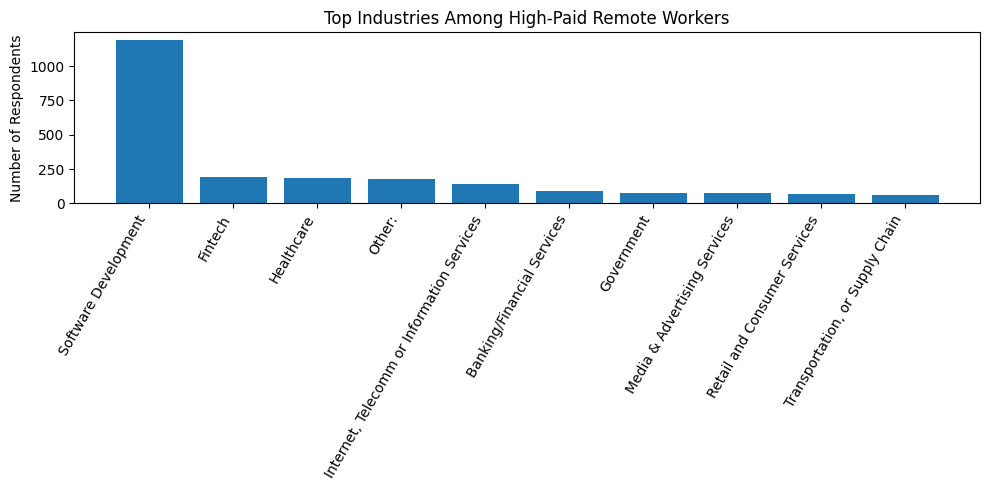

In [19]:
top_10_industries = top_industries_df.head(10)
plt.figure(figsize=(10, 5))
plt.bar(top_10_industries['Industry'],top_10_industries['Number of Respondents'])

plt.xticks(rotation=60, ha='right')
plt.ylabel('Number of Respondents')
plt.title('Top Industries Among High-Paid Remote Workers')

plt.tight_layout()
plt.show()

# Final Conclusions

## Key Findings

- Python is used by approximately 37.5% of respondents.
- Online courses remain one of the most popular learning methods.
- Developer compensation varies significantly across countries.
- Remote work is common among highly paid professionals.
- Technology-related industries are strongly represented among high-income remote workers.

## Skills Demonstrated

- Data Cleaning
- Data Aggregation
- Exploratory Data Analysis (EDA)
- Statistical Analysis
- Data Visualization
- Pandas
- Python